In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('Convictions_in_US.csv')

In [3]:
df.head(7)

,Unnamed: 0,Date of the Crime,Defendants,Type of the Crime,Location of the Crime,Punishment for a crime,Legally Exonerated,Legally Exonerated Encoded
0,0,1805,Dominic Daley and James Halligan,murder,Massachusetts,death,yes,1
1,1,1843,John Gordon,murder,Rhode Island,death,yes,1
2,2,1855,Chief Leschi,murder,Washington,death,no,0
3,3,1863,Chipita Rodriguez,murder,Texas,death,yes,1
4,4,1872,William Jackson Marion,murder,Nebraska,death,yes,1
5,5,1886,"Oscar Neebe, August Spies, and Albert Parsons",haymarket affair,Illinois,15 years,yes,1
6,6,1887,Charles Hudspeth,murder,Arkansas,death,yes,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Unnamed: 0                  178 non-null    int64 
 1   Date of the Crime           178 non-null    int64 
 2   Defendants                  178 non-null    object
 3   Type of the Crime           178 non-null    object
 4   Location of the Crime       178 non-null    object
 5   Punishment for a crime      169 non-null    object
 6   Legally Exonerated          178 non-null    object
 7   Legally Exonerated Encoded  178 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 11.3+ KB


In [5]:
df.describe()

,Unnamed: 0,Date of the Crime,Legally Exonerated Encoded
count,178.000000,178.000000,178.000000
mean,88.500000,1980.415730,0.859551
std,51.528309,34.544758,0.348433
min,0.000000,1805.000000,0.000000
25%,44.250000,1978.000000,1.000000
50%,88.500000,1986.500000,1.000000
75%,132.750000,1998.000000,1.000000
max,177.000000,2017.000000,1.000000


# 1. Обработка датасета

In [ ]:
sns.set_theme(style="whitegrid")
data = df.copy()

# Заполнение пропусков  модой 
mode_punishment = data['Punishment for a crime'].mode()[0]
data['Punishment for a crime'] = data['Punishment for a crime'].fillna(mode_punishment)

columns_to_drop = ['Unnamed: 0','Defendants', 'Legally Exonerated']

data = data.drop(columns=columns_to_drop, errors='ignore')

# Кодирование категориальных признаков
label_encoders = {}
categorical_cols = ['Type of the Crime', 'Location of the Crime', 'Punishment for a crime']

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le # Сохраняем энкодеры 

# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# Проверяем результат обработки
processed_df = pd.DataFrame(X_scaled, columns=data.columns)
display(processed_df.head())

,Date of the Crime,Type of the Crime,Location of the Crime,Punishment for a crime,Legally Exonerated Encoded
0,-5.092250,-0.323808,-0.237977,0.521872,0.404226
1,-3.989125,-0.323808,1.059702,0.521872,0.404226
2,-3.640770,-0.323808,1.523159,0.521872,-2.473863
3,-3.408533,-0.323808,1.337776,0.521872,0.404226
4,-3.147266,-0.323808,0.225480,0.521872,0.404226


# 2. Поиск оптимального числа кластеров (Метод локтя)

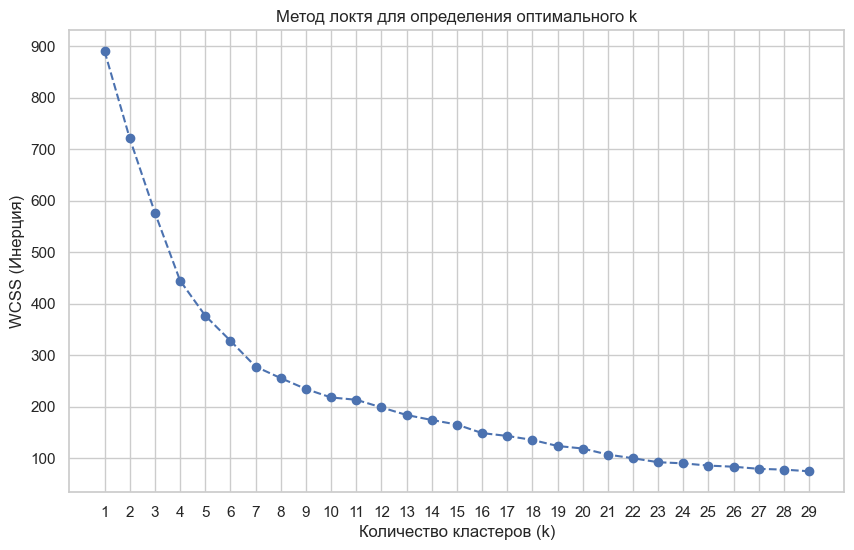

In [ ]:

wcss = [] # Энерция 
k_range = range(1, 30)

for i in k_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Метод локтя для определения оптимального k')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('WCSS (Инерция)')
plt.xticks(k_range)
plt.show()

# 3. Кластеризация K-Means++

In [ ]:
optimal_k = 7

# Обучение финальной модели
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(X_scaled)

df['Cluster'] = clusters

print(f"Размер каждого кластера:\n{df['Cluster'].value_counts().sort_index()}")

Размер каждого кластера:
Cluster
0    24
1    43
2    18
3    18
4    16
5    25
6    34
Name: count, dtype: int64


# 4. Описание полученных результатов

,Date of the Crime,Legally Exonerated Encoded
Cluster,,
0,1984.58,0.00
1,1986.67,1.00
2,1891.33,0.94
3,1996.83,1.00
4,1989.31,1.00
5,1999.92,1.00
6,1989.50,1.00



--- Кластер 0 ---
Самый частый тип преступления: murder
Самое частое наказание: death

--- Кластер 1 ---
Самый частый тип преступления: murder
Самое частое наказание: life in prison

--- Кластер 2 ---
Самый частый тип преступления: murder
Самое частое наказание: death

--- Кластер 3 ---
Самый частый тип преступления: rape
Самое частое наказание: 20 years

--- Кластер 4 ---
Самый частый тип преступления: rape
Самое частое наказание: life in prison

--- Кластер 5 ---
Самый частый тип преступления: murder
Самое частое наказание: 25 years

--- Кластер 6 ---
Самый частый тип преступления: murder
Самое частое наказание: life in prison


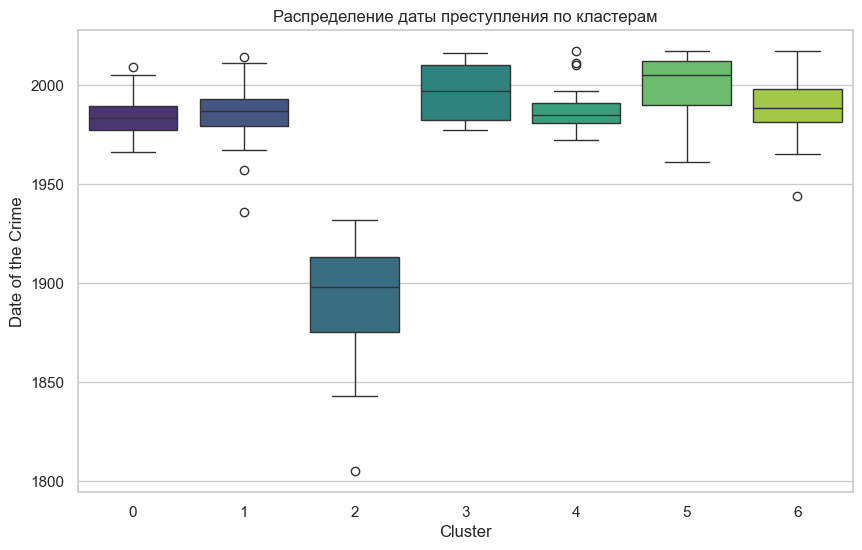

In [ ]:
display(df.groupby('Cluster')[['Date of the Crime', 'Legally Exonerated Encoded']].mean().round(2))

# самые частые значения категориальных признаков в каждом кластере
for cluster_num in sorted(df['Cluster'].unique()):
    print(f"\n--- Кластер {cluster_num} ---")
    cluster_data = df[df['Cluster'] == cluster_num]
    print("Самый частый тип преступления:", cluster_data['Type of the Crime'].mode().values[0])
    print("Самое частое наказание:", cluster_data['Punishment for a crime'].mode().values[0])
    
# распределение годов преступления по кластерам
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Date of the Crime', data=df, palette='viridis')
plt.title('Распределение даты преступления по кластерам')
plt.show()

# Вывод:
1. **Обработка данных:** Данные были очищены от пропусков (в признаке наказания пропуски заполнены модой), удалены неинформативные признаки (имена подсудимых). Категориальные признаки закодированы с помощью Label Encoding, а все данные стандартизированы с помощью StandardScaler для корректной работы метрических алгоритмов.
2. **Метод локтя:** Был построен график зависимости суммы квадратов внутрикластерных расстояний (WCSS) от количества кластеров. На графике наблюдается явный "излом" при **k = 7**. Это значение было выбрано как оптимальное количество кластеров.
3. **Результаты K-Means++:** Данные были успешно разбиты на 7 групп (кластеров). Алгоритм смог выявить скрытые паттерны в делах невинно осужденных.
4. **Описание кластеров:** Кластер 2 выделяется как исторически уникальный — средний год преступления составляет **1891**, диапазон охватывает дела вплоть до 1800-х годов; это преимущественно убийства со смертным приговором, большинство осуждённых (~94%) были юридически оправданы. Кластер 0 — наиболее тревожный: единственная группа с показателем юридического оправдания **0**, то есть ни один осуждённый официально реабилитирован не был (убийства, смертная казнь, средний год — 1984). Кластеры 3 и 5 представляют современные дела (1997 и 2000 гг.) с полным оправданием: кластер 3 — изнасилования с приговором 20 лет, кластер 5 — убийства с приговором 25 лет, что отражает активное применение ДНК-экспертизы в новейшую эпоху.




